# Machine Learning Tutorial Python - 13: K Means Clustering Algorithm
**K Means** **_clustering algorithm_** is **unsupervised machine learning** technique used to **_cluster data points._** In this tutorial we will go over some theory behind how **k means** works and then solve income group clustering problem using **sklearn, kmeans and python. Elbow** method is a technique used to determine <u>_optimal number of k,_</u> we will review that method as well.

Code: https://github.com/codebasics/py/blob/master/ML/13_kmeans/13_kmeans_tutorial.ipynb <br>
Credit: https://www.youtube.com/watch?v=EItlUEPCIzM&list=PLeo1K3hjS3uvCeTYTeyfe0-rN5r8zn9rw&index=14
#### Owner: Codebasics

# Machine Learning 3 Categories
   # 1. Supervised Learning
   # 2. Unsupervised Learning
   # 3. Reinforcement Learning

# Identity the cluster in this data set
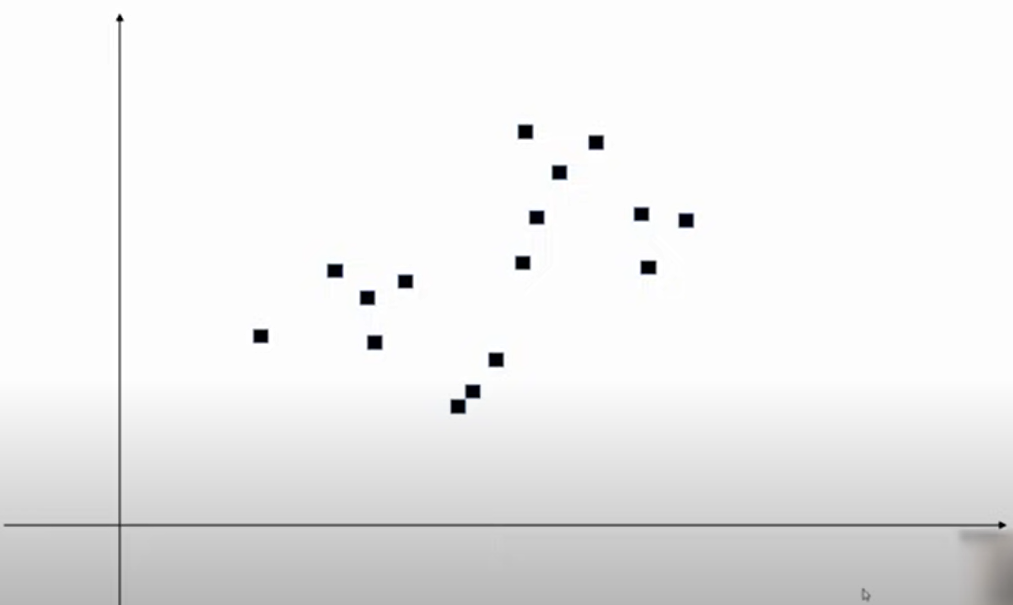

# Cluster Identification, K = 2  
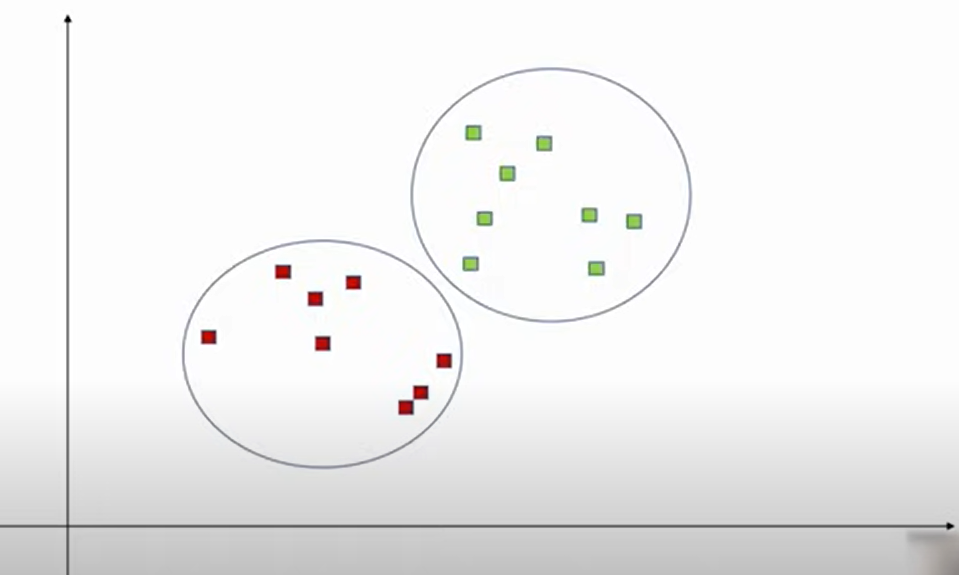

# Centroids
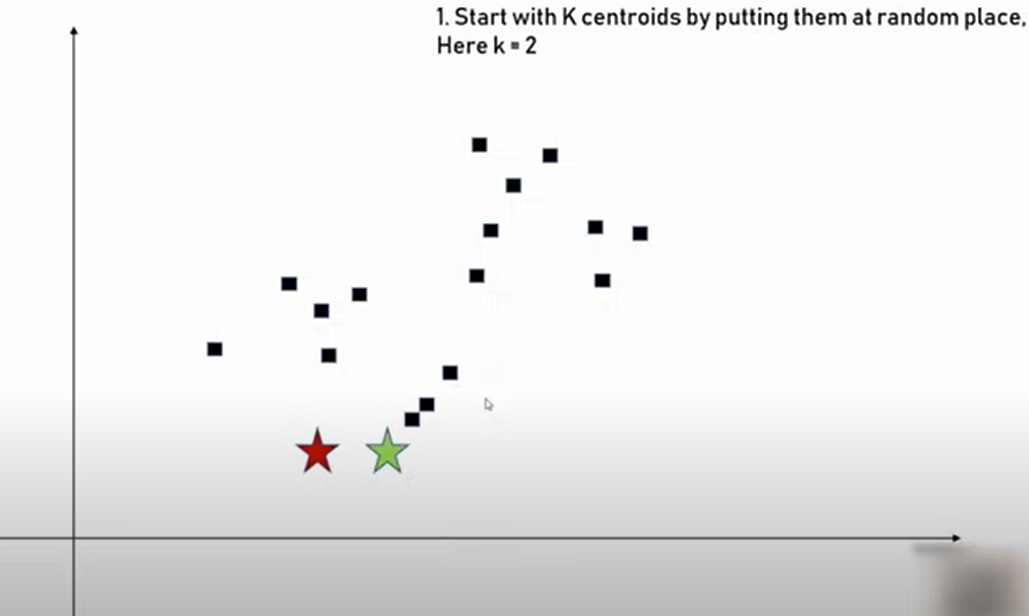

# Distance of Data point from Centroid
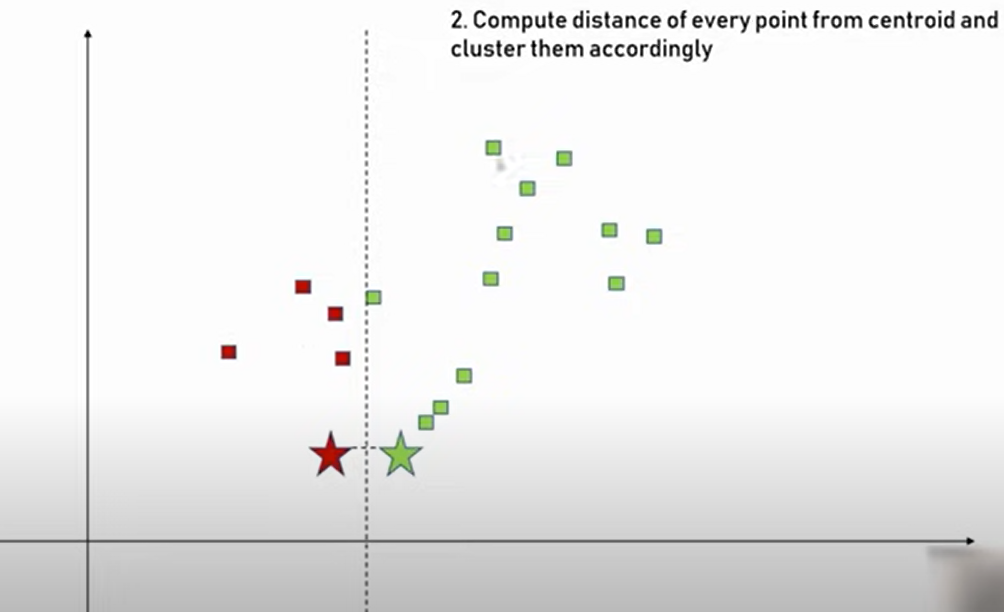

# Adjusment of Data point from Center
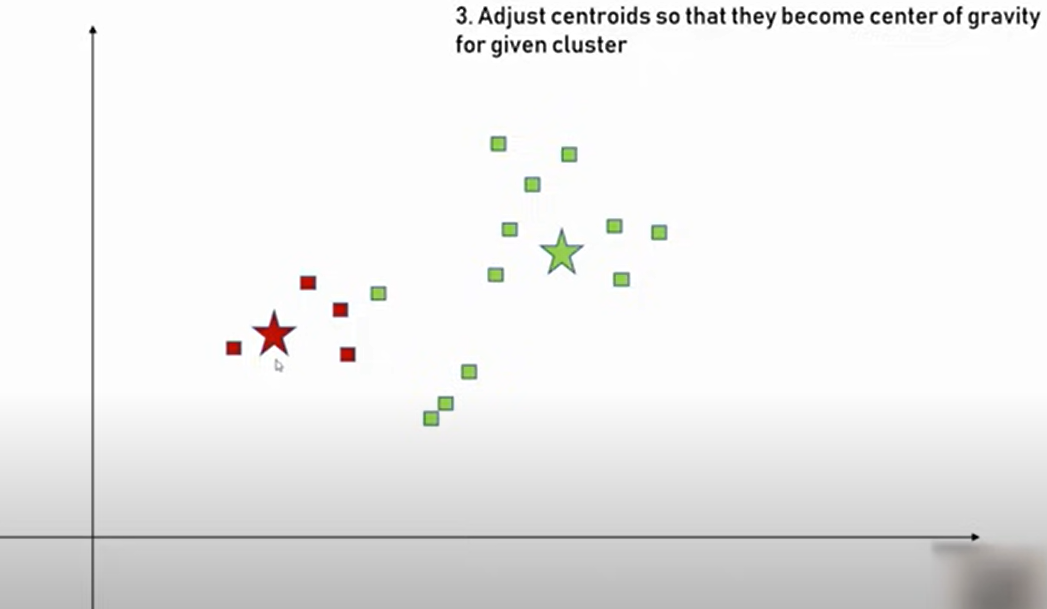

# Re-adjusment of Data point and Centroid
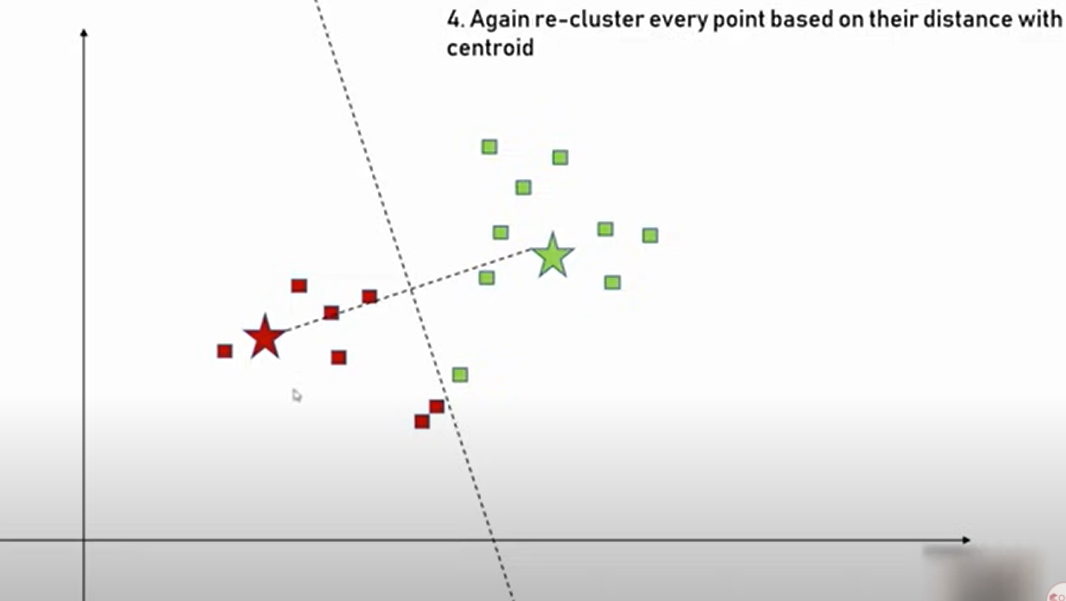

# Again, adjust the Centroids
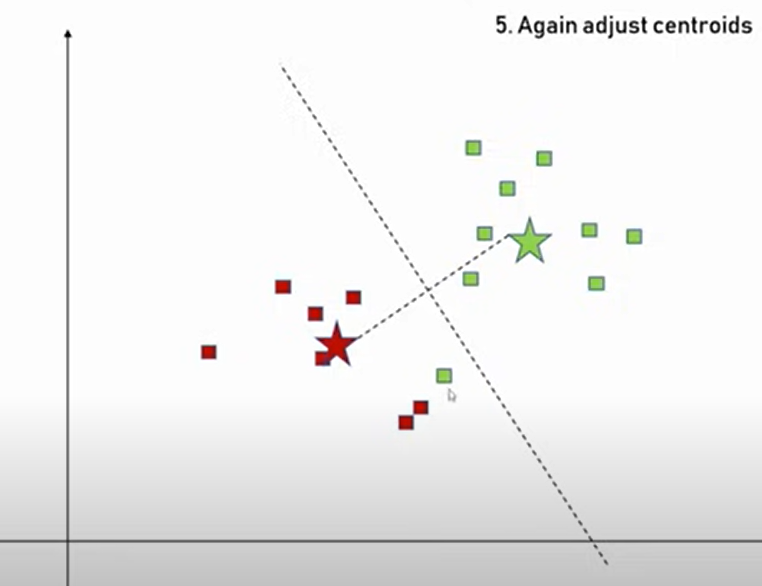

# Recomputation of Cluster
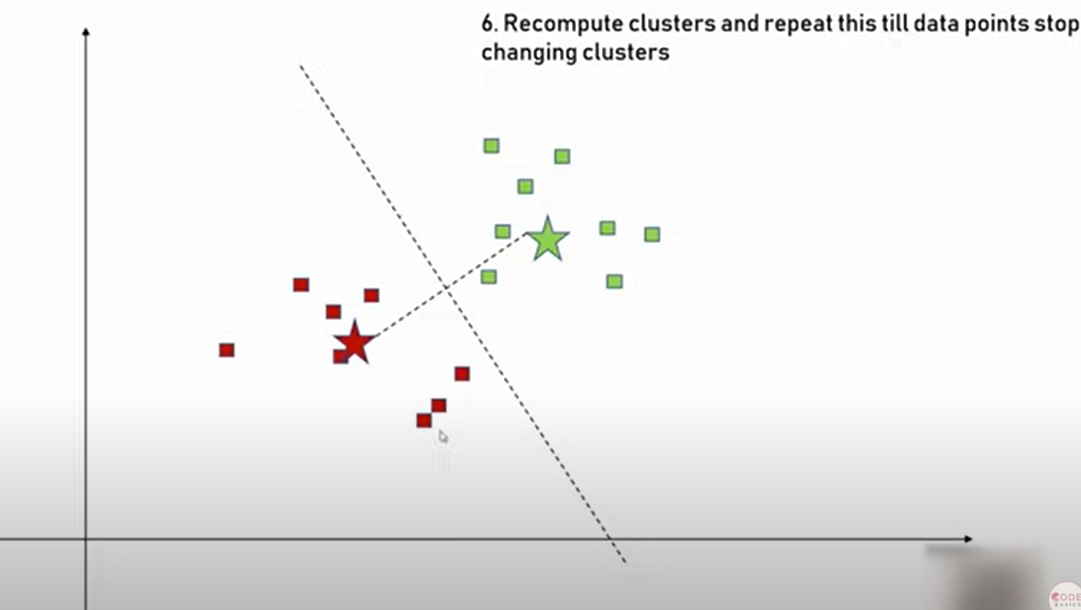

# Final, Cluster adjustment
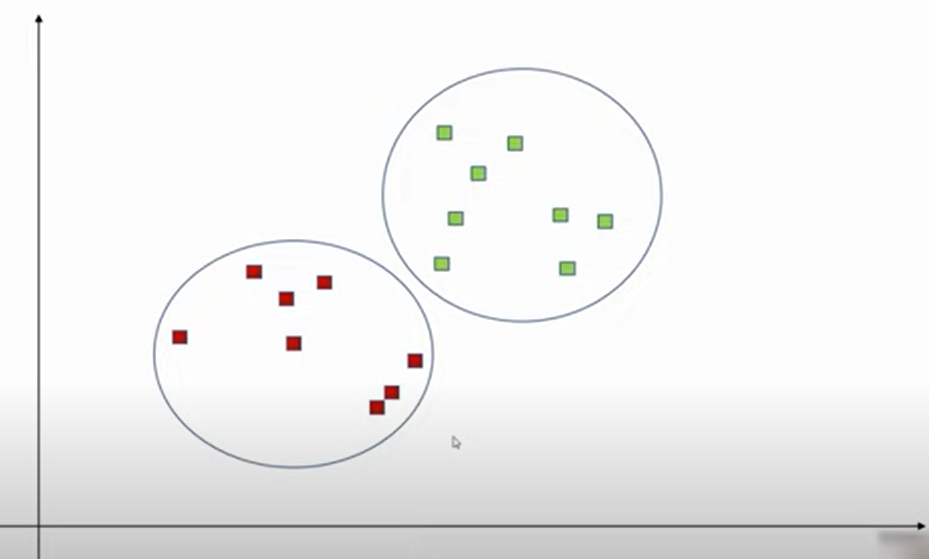

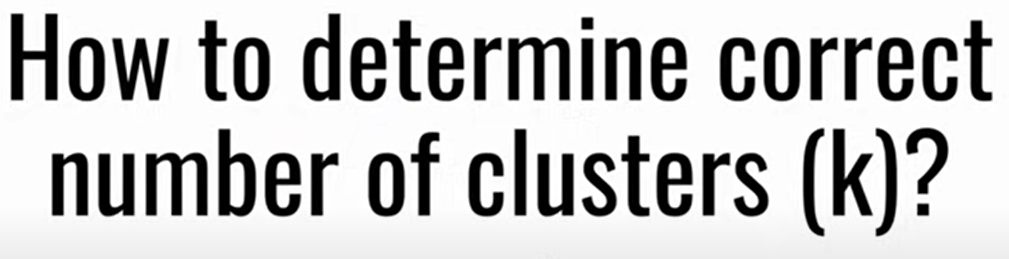

# Let's say K = 2, means 2 Cluster 

# SSE = Sum of Squared Error
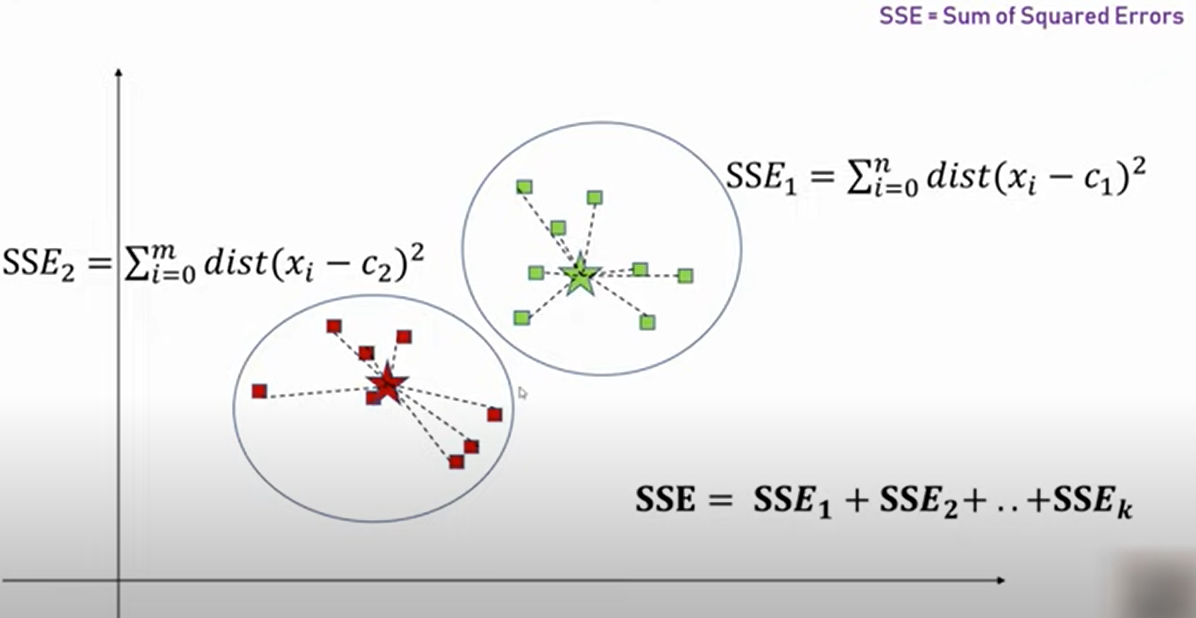

# Elbow Technique
## SSE Vs K Means
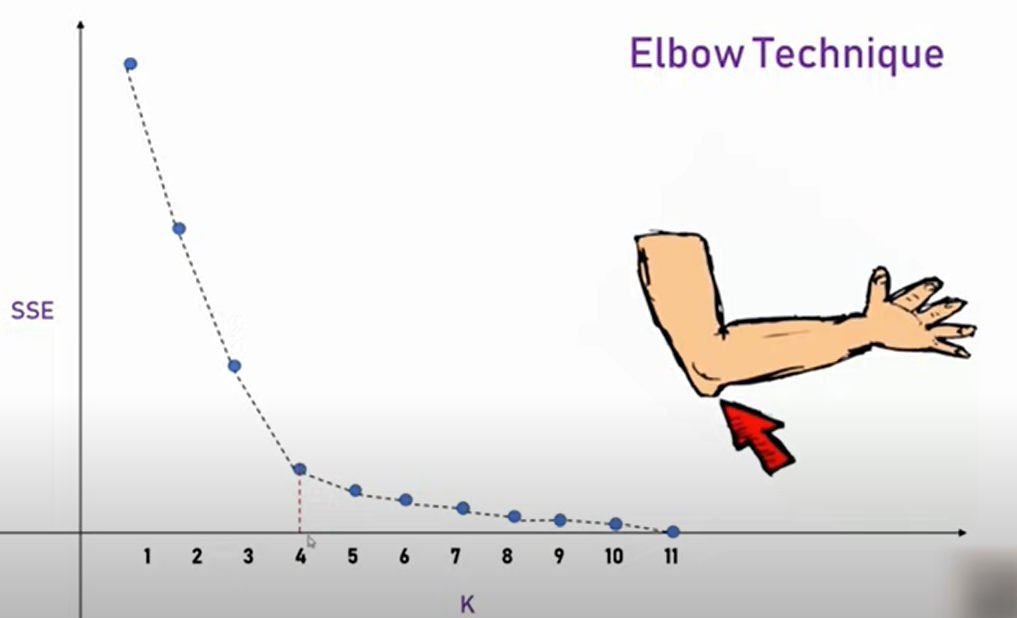

In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


Text(0, 0.5, 'Income ($)')

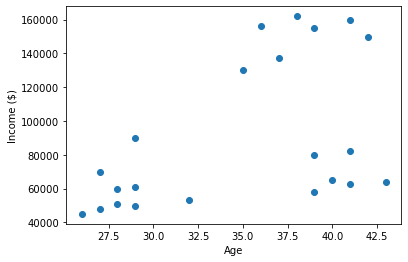

In [3]:
# Plot scatter plot
plt.scatter(df['Age'], df['Income($)']) # x-aixs, y-axis
plt.xlabel('Age')
plt.ylabel('Income ($)')

In [4]:
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [5]:
# training & test
y_predicted = km.fit_predict(df[['Age','Income($)']])
y_predicted

array([1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2])

In [6]:
df['cluster']=y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,1
1,Michael,29,90000,1
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,0


## Separate data point into 3 data set or 3 cluster

In [7]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

No handles with labels found to put in legend.


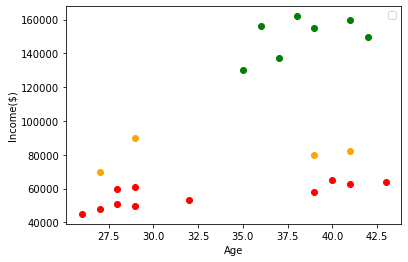

In [8]:
%matplotlib inline
plt.scatter(df1.Age, df1['Income($)'], color='green')
plt.scatter(df2.Age, df2['Income($)'], color='orange')
plt.scatter(df3.Age, df3['Income($)'], color='red')

#plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')

plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()

In [9]:
km.cluster_centers_ # x-axis, y-axis

array([[3.82857143e+01, 1.50000000e+05],
       [3.40000000e+01, 8.05000000e+04],
       [3.29090909e+01, 5.61363636e+04]])

## Preprocessing using min max scaler 

In [10]:
scaler = MinMaxScaler()
# scaler.fit(df['Income($)']) Two-dimensional array
scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,2
3,Ismail,0.117647,0.128205,2
4,Kory,0.941176,0.897436,0


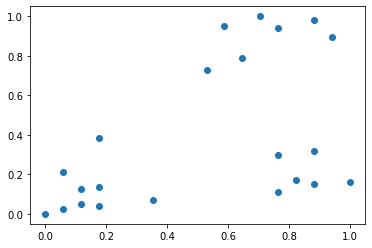

In [11]:
plt.scatter(df.Age, df['Income($)'])

In [12]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age', 'Income($)']])
y_predicted

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2])

In [13]:
df['cluster'] = y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [14]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

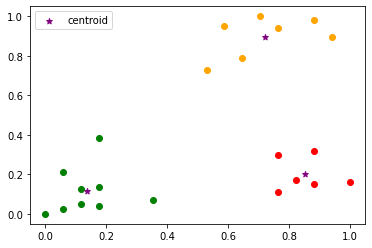

In [15]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='orange')
plt.scatter(df3.Age,df3['Income($)'],color='red')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

## Elbow Technique

In [16]:
k_rng = range(1,10)
sse = []
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [17]:
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553097,
 0.3491047094419566,
 0.2664030124668416,
 0.22508595962223268,
 0.1685851223602976,
 0.13781880133764024,
 0.10383752586603562]

## Elbow Plot 

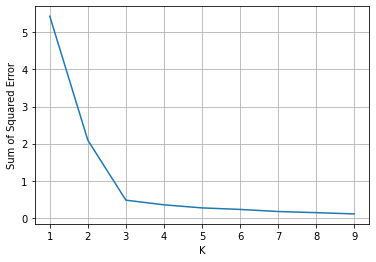

In [19]:
plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.plot(k_rng, sse)
plt.grid()

## Exercise
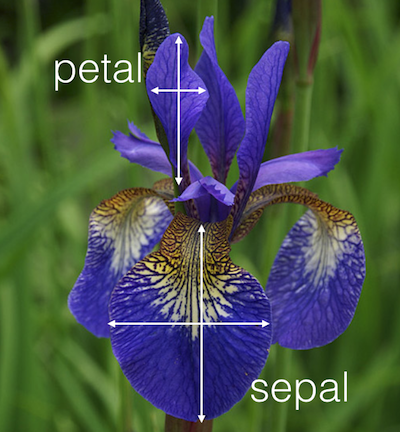

1. Use **iris flower dataset** from **sklearn library** and try to form **clusters** of flowers using **_petal width and length_** features. Drop other two features for simplicity.
2. Figure out if any preprocessing such as **scaling** would help here
3. Draw **elbow plot* and from that figure out **_optimal value of k_**